# 1. MLE
Ground-truth generation and estimator tests, the shared experiment settings (tagged `config`,
loaded by `2_hyperparameter_tuning.ipynb` and `3_main_experiments.ipynb`; save after editing), and the MLE run.

## Ground Truth Generation

In [1]:
%pip install networkx graphviz numpy pgmpy torch matplotlib ipywidgets nbformat

Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import os
import logging

import graphviz
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from ndbn.generation import gen_dag_indegree, gen_dag_max_indegree, gen_CPTs
from ndbn.mle import fit_mle, fit_mle_pseudocount
from ndbn.models import DEVICE, nn_probs
from ndbn.training import split_train_val, fit_nn
from ndbn.evaluation import kl_mle, kl_nn, mle_param_stats
from ndbn.experiments import run_experiments, run_sweep, arms_from_configs
import ndbn.plotting as plotting
from ndbn.plotting import plot_grouped_curves, plot_cardinality_wall

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"
logging.getLogger("pgmpy").setLevel(logging.ERROR)

print(DEVICE)
print(torch.__version__)        # e.g. 2.8.0+cpu  vs  2.8.0+cu126
print(torch.version.cuda)       # None  => CPU-only build
print(torch.cuda.device_count())

cuda
2.14.1+cu130
13.0
1


In [3]:
from IPython.display import HTML, display
display(HTML("""<style>
.cell-output-ipywidget-background { background-color: transparent !important; }
:root {
  --jp-widgets-color: var(--vscode-editor-foreground);
  --jp-widgets-font-size: var(--vscode-editor-font-size);
}
</style>"""))

### DAG Generation
`gen_dag_indegree`, `gen_dag_max_indegree` and `make_seed` live in `ndbn/generation.py`.

#### Test

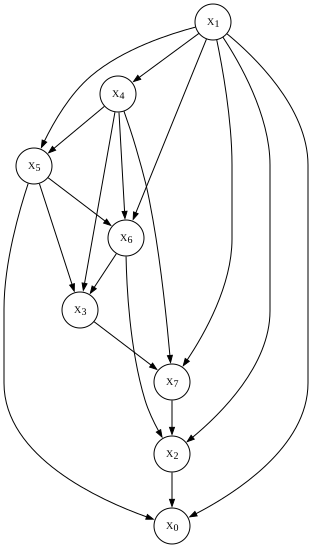

In [4]:
N_NODES = 8
CARDINALITY = 2
ALPHA = 1.0

MAX_IN_DEGREE = 3
MAX_DENSITY = 0.8

dag = gen_dag_indegree(
    n=N_NODES,
    k=MAX_IN_DEGREE,
    seed=123
)

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in dag.edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot

### Ground Truth CPTs
Populate ground-truth CPTs from Dirichlet (`gen_CPTs` in `ndbn/generation.py`).

#### Test

In [5]:
ground_truth = gen_CPTs(G=dag, card=CARDINALITY, alpha=ALPHA, seed=456)

for cpd in ground_truth.get_cpds():
    print(f"{cpd} \n")

+--------+----------+
| X_1(0) | 0.538859 |
+--------+----------+
| X_1(1) | 0.461141 |
+--------+----------+ 

+--------+---------------------+----------------------+
| X_1    | X_1(0)              | X_1(1)               |
+--------+---------------------+----------------------+
| X_4(0) | 0.32406706937795593 | 0.981314983195667    |
+--------+---------------------+----------------------+
| X_4(1) | 0.6759329306220442  | 0.018685016804333033 |
+--------+---------------------+----------------------+ 

+--------+---------------------+-----+---------------------+
| X_1    | X_1(0)              | ... | X_1(1)              |
+--------+---------------------+-----+---------------------+
| X_4    | X_4(0)              | ... | X_4(1)              |
+--------+---------------------+-----+---------------------+
| X_5(0) | 0.06863164792155352 | ... | 0.5398787090259637  |
+--------+---------------------+-----+---------------------+
| X_5(1) | 0.9313683520784465  | ... | 0.46012129097403637 |
+-----

### Evaluation Functions
KL divergence against the ground truth, parameter counts and fit timing live in `ndbn/evaluation.py`.

### MLE
`fit_mle` and `fit_mle_pseudocount` live in `ndbn/mle.py`.

#### Test


In [6]:
N, CARD, ALPHA = 2000, 2, 1.0

G = gen_dag_indegree(n=8, k=3, seed=123)
n = G.number_of_nodes()

print(f"Max in-degree = {3}")
print(f"\nDensity: {G.number_of_edges() / (n*(n-1)/2):.3f}")
print("In-degrees:", dict(sorted(G.in_degree(), key=lambda kv: kv[0])))

ground_truth = gen_CPTs(G=G, card=CARDINALITY, alpha=ALPHA, seed=456)

# sample
data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
test_data = ground_truth.simulate(n_samples=N, seed=4, show_progress=False)
print(f"\nSampled {len(data)} rows")

# parameter estimation
mle_model = fit_mle(G, data, CARD)

kl, se = kl_mle(ground_truth, mle_model, test_data)
print(f"KL = {kl:>10.4f}")

Max in-degree = 3

Density: 0.643
In-degrees: {'X_0': 3, 'X_1': 0, 'X_2': 3, 'X_3': 3, 'X_4': 1, 'X_5': 2, 'X_6': 3, 'X_7': 3}


c:\Users\Kaylin\Documents\Neural-Discrete-Bayesian-Network\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (



Sampled 2000 rows
KL =     0.0149


## Neural Network CPDs
Model in `ndbn/models.py`, training loop in `ndbn/training.py`, W&B diagnostics in `ndbn/tracing.py`.

#### Test


In [7]:
# ── Smoke test: NN CPDs run end to end ───────────────────────────────────────
G = gen_dag_indegree(n=5, k=2, seed=0)
true_model = gen_CPTs(G, CARD, alpha=1.0, seed=1)

data = true_model.simulate(n_samples=1000, seed=2, show_progress=False)
test_data = true_model.simulate(n_samples=2000, seed=3, show_progress=False)
train_df, val_df = split_train_val(data, val_frac=0.2, seed=0)

mle = fit_mle(G, data, CARD)   # MLE gets train + val, like the experiments
nn_model = fit_nn(G, train_df, CARD, val_data=val_df, n_epochs=100, verbose=True)

kl_m, _ = kl_mle(true_model, mle, test_data)
kl_n, _ = kl_nn(true_model, nn_model, test_data, CARD)

# probabilities are valid
q = nn_probs(nn_model["X_0"], test_data, CARD)
assert q.shape == (len(test_data), CARD)
assert np.allclose(q.sum(axis=1), 1.0)

print(f"KL  MLE {kl_m:.4f}   NN {kl_n:.4f}")
print(f"params  MLE {mle_param_stats(mle)['stored_params']}"
      f"   NN {nn_model.param_stats()['stored_params']}")


c:\Users\Kaylin\Documents\Neural-Discrete-Bayesian-Network\ndbn\models.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  idx = torch.as_tensor(data[parents].to_numpy(np.int64), device=DEVICE)


Node X_3 early stopped at epoch 38. Best val loss=0.4693
Node X_2 early stopped at epoch 40. Best val loss=0.4812
Epoch 50, val 0.4306
Node X_4 early stopped at epoch 51. Best val loss=0.5117
Epoch 100, val 0.3883
KL  MLE 0.0199   NN 0.0089
params  MLE 30   NN 970


## Experiments (MLE)
The grid loop lives in `ndbn/experiments.py`. The config cell below is **shared with `2_hyperparameter_tuning.ipynb` and
`3_main_experiments.ipynb`** (it is tagged `config`; they load it from the saved file, so save this notebook after
editing it). This section runs **MLE only**, into `RESULTS_CSV`, the same results file the main
experiments use; the grid is resumable (configs already in the CSV are skipped), so the main run
later skips these MLE configs.

Speed settings (`N_JOBS`, `DEVICE_OVERRIDE`, `TORCH_THREADS`) run independent DAGs in parallel
CPU processes; `N_JOBS = 1` restores the old serial loop. Results match a serial run on the same
device, but per-fit times are inflated by contention, so **training time comes only from the
serial timing run** in `3_main_experiments.ipynb`.

In [8]:
# experiment configs (tagged "config": 2_hyperparameter_tuning.ipynb and 3_main_experiments.ipynb load the tagged cells from the saved notebook)
import os

NODE_COUNTS  = [5, 10, 20, 30, 40]
IN_DEGREES   = [2, 4, 6, 10] # max_in_degree
ALPHAS       = [0.1, 0.5, 1.0] # sparse/peaked -> flat/uniform
SIM          = 5 # random DAGs per config

CARD         = 2 # results rows, data caches, resume checks and plots are all keyed on
                 # card, so runs with different cardinalities can share one results CSV
SAMPLE_SIZES     = [600, 1000, 1400] #train+val
VAL_FRAC         = 0.2
N_TEST           = 10000
N_EPOCHS         = 200

RESULTS_DIR = "results5-parallel"
os.makedirs(RESULTS_DIR, exist_ok=True)
# one results file for MLE (this section) and every estimator (Experiments 2.0)
RESULTS_NAME = "results.csv"
RESULTS_CSV  = os.path.join(RESULTS_DIR, RESULTS_NAME)
TIMING_CSV   = os.path.join(RESULTS_DIR, "results_timing.csv")
TRIALS_CSV   = os.path.join(RESULTS_DIR, "hparam_trials.csv")     # tuning data: sweep trials + chosen configs
CHOSEN_JSON  = os.path.join(RESULTS_DIR, "chosen_nn.json")        # final NN config(s) for the main experiments

# speed settings (used by the main experiment and all sweeps)
N_JOBS          = -1     # worker processes; -1 = all cores, 1 = serial (old behaviour)
DEVICE_OVERRIDE = "cpu"  # None = auto (cuda if available); tiny per-node nets run best on CPU
TORCH_THREADS   = 1      # torch threads per worker

VERBOSE = True

In [9]:
# MLE only; Experiments 2.0 writes to the same CSV and skips these configs
run_experiments(
    node_counts=NODE_COUNTS, in_degrees=IN_DEGREES, alphas=ALPHAS, n_dags=SIM,
    sample_sizes=SAMPLE_SIZES, estimators=[{"name": "mle", "type": "mle"}], card=CARD,
    val_frac=VAL_FRAC, n_test=N_TEST, n_epochs=N_EPOCHS,
    results_dir=RESULTS_DIR, verbose=VERBOSE, results_name=RESULTS_NAME,
    n_jobs=N_JOBS, device=DEVICE_OVERRIDE, torch_threads=TORCH_THREADS,
)

loaded results: n=5 k=2 alpha=0.1
loaded results: n=5 k=2 alpha=0.5
loaded results: n=5 k=2 alpha=1.0
loaded results: n=5 k=4 alpha=0.1
loaded results: n=5 k=4 alpha=0.5
loaded results: n=5 k=4 alpha=1.0
loaded results: n=5 k=6 alpha=0.1
loaded results: n=5 k=6 alpha=0.5
loaded results: n=5 k=6 alpha=1.0
loaded results: n=5 k=10 alpha=0.1
loaded results: n=5 k=10 alpha=0.5
loaded results: n=5 k=10 alpha=1.0
loaded results: n=10 k=2 alpha=0.1
loaded results: n=10 k=2 alpha=0.5
loaded results: n=10 k=2 alpha=1.0
loaded results: n=10 k=4 alpha=0.1
loaded results: n=10 k=4 alpha=0.5
loaded results: n=10 k=4 alpha=1.0
loaded results: n=10 k=6 alpha=0.1
loaded results: n=10 k=6 alpha=0.5
loaded results: n=10 k=6 alpha=1.0
loaded results: n=10 k=10 alpha=0.1
loaded results: n=10 k=10 alpha=0.5
loaded results: n=10 k=10 alpha=1.0
loaded results: n=20 k=2 alpha=0.1
loaded results: n=20 k=2 alpha=0.5
loaded results: n=20 k=2 alpha=1.0
loaded results: n=20 k=4 alpha=0.1
loaded results: n=20 k=4 a

DAGs: 0it [00:00, ?it/s]